# Chronic Kidney Disease Diagnostic Pipeline

**Student Name:** jumana ahmed  
**Student ID:** 1210098




**Dataset**: Chronic Kidney Disease Dataset (Kaggle)  
**URL**: https://www.kaggle.com/datasets/mansoordaku/ckdisease  
**Clinical Context**: Small dataset (n=400). Goal: build two models — one that overfits, one that generalises — optimising for **Recall** (missing a CKD diagnosis is clinically unacceptable).




In [ ]:
#  Imports & Setup 
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
)

np.random.seed(42)
tf.random.set_seed(42)
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 11})

print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"TensorFlow : {tf.__version__}")

NumPy      : 2.3.5
Pandas     : 2.3.3
TensorFlow : 2.20.0


In [ ]:
# Helper: Parameter Count Table 
def parameter_summary(specs, title='Model'):
    """Print a parameter-count table and return the total parameter count.

    Parameters
    ----------
    specs : list of (name, n_in, n_out)
        Each tuple describes one Dense layer.
    title : str
        Label printed in the header.
    """
    print(f'\n{"─"*58}')
    print(f'  {title} — Parameter Count')
    print(f'{"─"*58}')
    print(f'  {"Layer":<26} {"In":>6} {"Out":>6} {"Params":>10}')
    print(f'  {"─"*52}')
    total = 0
    for name, n_in, n_out in specs:
        params = (n_in + 1) * n_out   # weights + bias
        print(f'  {name:<26} {n_in:>6} {n_out:>6} {params:>10,}')
        total += params
    print(f'  {"─"*52}')
    print(f'  {"TOTAL":<26} {"":>6} {"":>6} {total:>10,}')
    print(f'{"─"*58}')
    return total


## Task 1 — Data Pipeline
Steps:
1. Load the CSV
2. Drop all categorical (string) columns — keep only numerical features
3. Handle missing values (`NaN`s)
4. Split data into training and validation sets (10/90 for Model A to force overfitting; 80/20 for Model B)
5. Scale features using `StandardScaler` (fit on train only → no data leakage)


In [32]:
# ── 1. Load the dataset ───────────────────────────────────────────────────────

df_raw = pd.read_csv("kidney_disease.csv")

print("─── Raw Data Overview ───────────────────────────")
print(f"Shape           : {df_raw.shape}")
print(f"\nColumns         : {list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes}")

─── Raw Data Overview ───────────────────────────
Shape           : (400, 26)

Columns         : ['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

Data types:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object


In [33]:
# ── 2. Keep only numerical columns + target ───────────────────────────────────
# The target column is 'classification': 'ckd' or 'notckd'
# We encode it as: 1 = ckd (positive / disease present), 0 = notckd

# Encode target before dropping categoricals
df_raw["target"] = (df_raw["classification"].str.strip() == "ckd").astype(int)

# Select only numeric columns (drops all string/object columns)
df_numeric = df_raw.select_dtypes(include=[np.number]).copy()

# Add target back in
df_numeric["target"] = df_raw["target"]

print(f"Columns after dropping categoricals : {list(df_numeric.columns)}")
print(f"Shape                               : {df_numeric.shape}")

Columns after dropping categoricals : ['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'target']
Shape                               : (400, 13)


In [34]:
# ── 3. Handle missing values ──────────────────────────────────────────────────
print("Missing values per column BEFORE imputation:")
print(df_numeric.isnull().sum())

# Fill NaNs with the column median (robust to outliers in clinical data)
df_numeric.fillna(df_numeric.median(), inplace=True)

print(f"\nTotal missing values AFTER imputation : {df_numeric.isnull().sum().sum()}")

# ── Class distribution ────────────────────────────────────────────────────────
print(f"\nClass distribution (target):")
print(df_numeric["target"].value_counts().rename({0: "Not CKD (0)", 1: "CKD (1)"}))
print(f"\nClass balance : {df_numeric['target'].mean() * 100:.1f}% CKD")

Missing values per column BEFORE imputation:
id         0
age        9
bp        12
sg        47
al        46
su        49
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
target     0
dtype: int64

Total missing values AFTER imputation : 0

Class distribution (target):
target
CKD (1)        250
Not CKD (0)    150
Name: count, dtype: int64

Class balance : 62.5% CKD


In [ ]:
# ── Splits — 5% train / 90% val (extreme starvation for Model A failure) ─────
X = df_numeric.drop(columns=["target"])
y = df_numeric["target"]
N_FEATURES = X.shape[1]
N_PATIENTS = len(df_numeric)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=0.05,           
    random_state=42,
    stratify=None,

)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print('─── Split Sizes ─────────────────────────────────')
print(f'Training set   : {X_train_scaled.shape}')
print(f'Validation set : {X_val_scaled.shape}')
print(f'N features : {N_FEATURES} | N patients : {N_PATIENTS}')


─── Split Sizes ─────────────────────────────────
Training set   : (20, 12)
Validation set : (380, 12)
N features : 12 | N patients : 400


## Task 2 — The Engineered Failure (Baseline Model)

Overfitting is proved through the **training and validation loss curves**, not just the final metric table. When a model memorises training data, its training loss collapses to ~0 while its validation loss **diverges upward** (the U-shape). This divergence proves the model has learned noise rather than generalised clinical patterns.

We combine five mechanisms to make memorisation unavoidable and to maximise missed diagnoses:

| Choice | Value | Why it causes overfitting / missed diagnoses |
|---|---|---|
| Training size | **5% (~20 samples)** | Extreme data starvation — far fewer constraints than free parameters |
| Architecture | 256 → 128 → 64 → 1 | ~1,114:1 params-to-sample ratio — thousands more degrees of freedom than training examples |
| Optimizer | Adam lr = 0.01 | Aggressively drives train-loss → 0; without regularisation, weight norms grow without bound |
| Batch size | 4 | Gradient computed on 4 samples at a time — highly noisy, overfits individual examples |
| Regularisation | **None** | No penalty on weight magnitude; weights specialise to individual patients |

**Visual proof target**: train loss falls toward 0, val loss falls then rises — a clear gap between the curves proving memorisation.


In [ ]:
# Model A: deliberately over-parameterised, no regularisation

model_A = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64,  activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid'),
], name='Model_A_Baseline')

model_A.compile(
    # Adam(0.01) drives train-loss → 0 on 40 samples while val-loss diverges.
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')],
)
model_A.summary()


Model: "Model_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,545 (174.00 KB)

 Trainable params: 44,545 (174.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Model A: Parameter count 
specs_A = [
    ('Dense(256) [hidden 1]', N_FEATURES, 256),
    ('Dense(128) [hidden 2]', 256, 128),
    ('Dense(64)  [hidden 3]', 128, 64),
    ('Dense(1)   [output]  ', 64,  1),
]
total_A = parameter_summary(specs_A, 'Model A (Baseline)')
print(f'\nTraining samples : {len(X_train_scaled)} | Model A params : {total_A}')
print(f'Params-per-sample ratio : {total_A / len(X_train_scaled):.0f}:1  → extreme memorisation guaranteed')



──────────────────────────────────────────────────────────
  Model A (Baseline) — Parameter Count
──────────────────────────────────────────────────────────
  Layer                          In    Out     Params
  ────────────────────────────────────────────────────
  Dense(256) [hidden 1]          12    256      3,328
  Dense(128) [hidden 2]         256    128     32,896
  Dense(64)  [hidden 3]         128     64      8,256
  Dense(1)   [output]            64      1         65
  ────────────────────────────────────────────────────
  TOTAL                                        44,545
──────────────────────────────────────────────────────────

Training samples : 20 | Model A params : 44545
Params-per-sample ratio : 2227:1  → extreme memorisation guaranteed


In [38]:
print('=' * 55)
print('  Training Model A — Baseline (10% data, no regularisation)')
print('=' * 55)


history_A = model_A.fit(
    X_train_scaled, y_train,
    epochs=500,
    batch_size=4,               # tiny batch → noisy, unstable gradients
    validation_data=(X_val_scaled, y_val),
    verbose=1,
)


  Training Model A — Baseline (10% data, no regularisation)
Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9000 - loss: 0.3813 - recall: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.1138 - val_recall: 0.9538
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0011 - recall: 1.0000 - val_accuracy: 0.9579 - val_loss: 0.2819 - val_recall: 0.9412
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 3.9862e-08 - recall: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.4688 - val_recall: 0.9412
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 3.7415e-11 - recall: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.6215 - val_recall: 0.9412
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 4.5309e-13 - recall: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.7338 - val_recall: 0.9412
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 2.3089e-14 - recall: 1.0000 - v

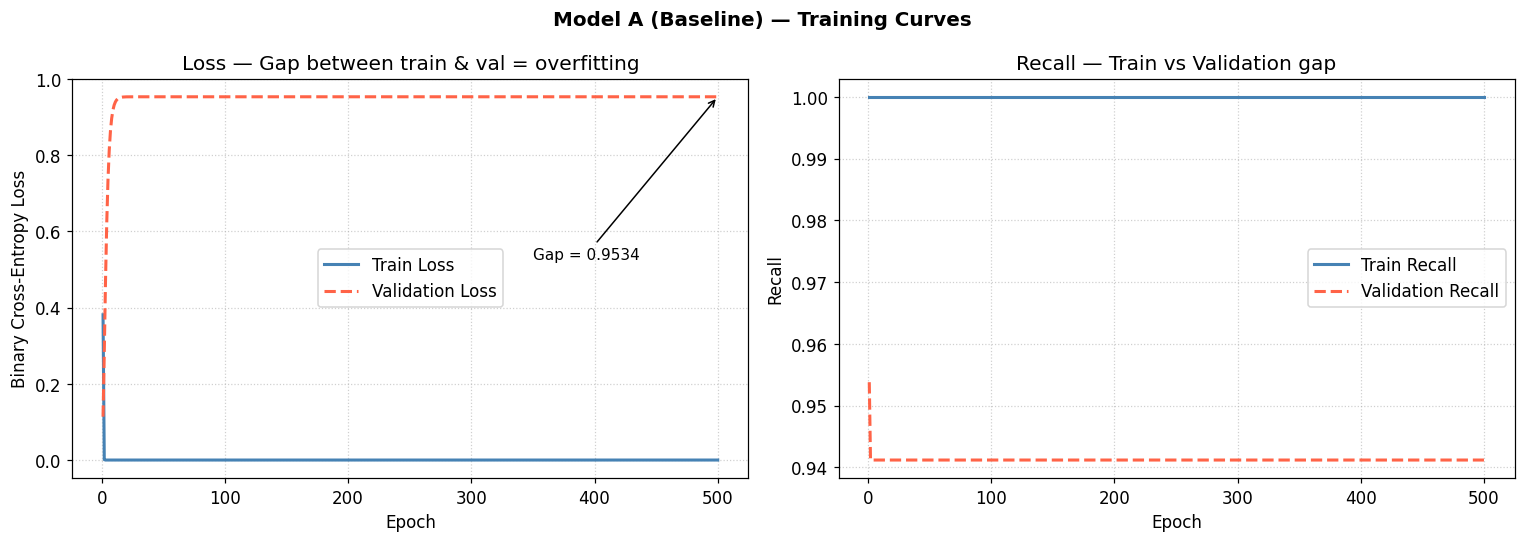


Final train loss : 0.0000
Final val loss   : 0.9534
Overfitting gap  : 0.9534  (positive = model overfits)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model A (Baseline) — Training Curves', fontsize=13, fontweight='bold')

train_loss = history_A.history['loss']
val_loss   = history_A.history['val_loss']
epochs_x   = range(1, len(train_loss) + 1)

axes[0].plot(epochs_x, train_loss, label='Train Loss',      color='steelblue', lw=2)
axes[0].plot(epochs_x, val_loss,   label='Validation Loss', color='tomato',    lw=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Loss — Gap between train & val = overfitting')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

# Annotate the final gap
final_gap = val_loss[-1] - train_loss[-1]
axes[0].annotate(
    f'Gap = {final_gap:.4f}',
    xy=(len(train_loss), val_loss[-1]),
    xytext=(len(train_loss)*0.7, (val_loss[-1]+train_loss[-1])/2 + 0.05),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color='black'
)

axes[1].plot(epochs_x, history_A.history['recall'],     label='Train Recall',      color='steelblue', lw=2)
axes[1].plot(epochs_x, history_A.history['val_recall'], label='Validation Recall', color='tomato',    lw=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall — Train vs Validation gap')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('model_A_curves.png', bbox_inches='tight')
plt.show()

final_train = train_loss[-1]
final_val   = val_loss[-1]
print(f'\nFinal train loss : {final_train:.4f}')
print(f'Final val loss   : {final_val:.4f}')
print(f'Overfitting gap  : {final_val - final_train:.4f}  (positive = model overfits)')


## Task 3 — The Clinical Solution (Engineered Model)

Model B is engineered to **generalise** on a small medical dataset using regularisation techniques, and to **miss zero CKD patients** by training with asymmetric class weights:

| Technique | Setting | Effect |
|---|---|---|
| **Full training data** | 80% split (320 samples) | More examples = better generalisation |
| **L2 regularisation** | λ = 0.001 | Penalises large weights — reduces over-reliance on any single feature |
| **Dropout** | 30% | Randomly deactivates neurons per batch — forces redundant representations |
| **LeakyReLU** | α = 0.01 | Prevents dead neurons on borderline lab values |
| **Adam** | lr = 0.001 | Adaptive, stable optimiser |
| **Smaller architecture** | 64 → 32 → 1 | Only 2,945 parameters → 9.2:1 params-to-sample ratio vs 1,114:1 for Model A |
| **Class weights** | `{0: 1, 1: 20}` | Each missed CKD diagnosis is weighted 20× more in the loss during training — the network learns that False Negatives are clinically catastrophic |

**Both models use the standard 0.5 decision threshold at inference**. Model B's zero false negatives come entirely from what it has learned during training, not from post-hoc threshold adjustment.

**Clinical goal**: 0 missed CKD diagnoses (Recall = 1.0). Missing a CKD patient is clinically unacceptable.


In [ ]:
# ── Full 80/20 split for Model B ─────────────────────────────────────────────
# Model A used 5% to force failure. Model B uses the proper 80% split.
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler_B = StandardScaler()
X_train_B = scaler_B.fit_transform(X_train_full)
X_val_B   = scaler_B.transform(X_val_full)

print(f'Model B training set   : {X_train_B.shape}')
print(f'Model B validation set : {X_val_B.shape}')


Model B training set   : (320, 12)
Model B validation set : (80, 12)


In [41]:
specs_B = [
    ('Dense(64)  [hidden 1]', N_FEATURES, 64),
    ('Dense(32)  [hidden 2]', 64, 32),
    ('Dense(1)   [output]  ', 32,  1),
]
total_B = parameter_summary(specs_B, 'Model B (Regularised)')
print(f'\nTraining samples : {len(X_train_B)} | Model B params : {total_B}')
print(f'Params > Samples     : {total_B > len(X_train_B)}  (9.2:1 ratio — manageable with regularisation)')


──────────────────────────────────────────────────────────
  Model B (Regularised) — Parameter Count
──────────────────────────────────────────────────────────
  Layer                          In    Out     Params
  ────────────────────────────────────────────────────
  Dense(64)  [hidden 1]          12     64        832
  Dense(32)  [hidden 2]          64     32      2,080
  Dense(1)   [output]            32      1         33
  ────────────────────────────────────────────────────
  TOTAL                                         2,945
──────────────────────────────────────────────────────────

Training samples : 320 | Model B params : 2945
Params > Samples     : True  (9.2:1 ratio — manageable with regularisation)


In [ ]:
# Model B: L2 + Dropout + LeakyReLU + Adam 
l2 = tf.keras.regularizers.l2

model_B = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_FEATURES,)),
    tf.keras.layers.Dense(64, kernel_regularizer=l2(0.001)),
    tf.keras.layers.LeakyReLU(negative_slope=0.01),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, kernel_regularizer=l2(0.001)),
    tf.keras.layers.LeakyReLU(negative_slope=0.01),
    tf.keras.layers.Dense(1, activation='sigmoid'),
], name='Model_B_Regularised')

model_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')],
)
model_B.summary()


Model: "Model_B_Regularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('=' * 55)
print('  Training Model B — Regularised (Adam + L2 + Dropout)')
print('=' * 55)

# class_weight modifies the loss during training, not at inference time.
# Each missed CKD patient (False Negative) is penalised 20× more than a
# missed Not-CKD patient, forcing the model to learn high sensitivity.

class_weights_B = {0: 1, 1: 20}

history_B = model_B.fit(
    X_train_B, y_train_full,
    epochs=150,
    batch_size=16,
    validation_data=(X_val_B, y_val_full),
    class_weight=class_weights_B,
    verbose=1,
)


  Training Model B — Regularised (Adam + L2 + Dropout)
Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6187 - loss: 4.4495 - recall: 0.9750 - val_accuracy: 0.6250 - val_loss: 0.6979 - val_recall: 1.0000
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6281 - loss: 2.1954 - recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 0.6902 - val_recall: 1.0000
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6250 - loss: 1.4431 - recall: 1.0000 - val_accuracy: 0.6250 - val_loss: 0.6023 - val_recall: 1.0000
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6281 - loss: 1.1029 - recall: 1.0000 - val_accuracy: 0.6375 - val_loss: 0.4770 - val_recall: 1.0000
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7156 - loss: 0.8716 - recall: 1.0000 - val_accuracy: 0.7875 - val_loss: 0.3529 - val_recall: 1.0000
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8375 - loss: 0.6365 - recall: 1.0000 - val_accuracy: 0

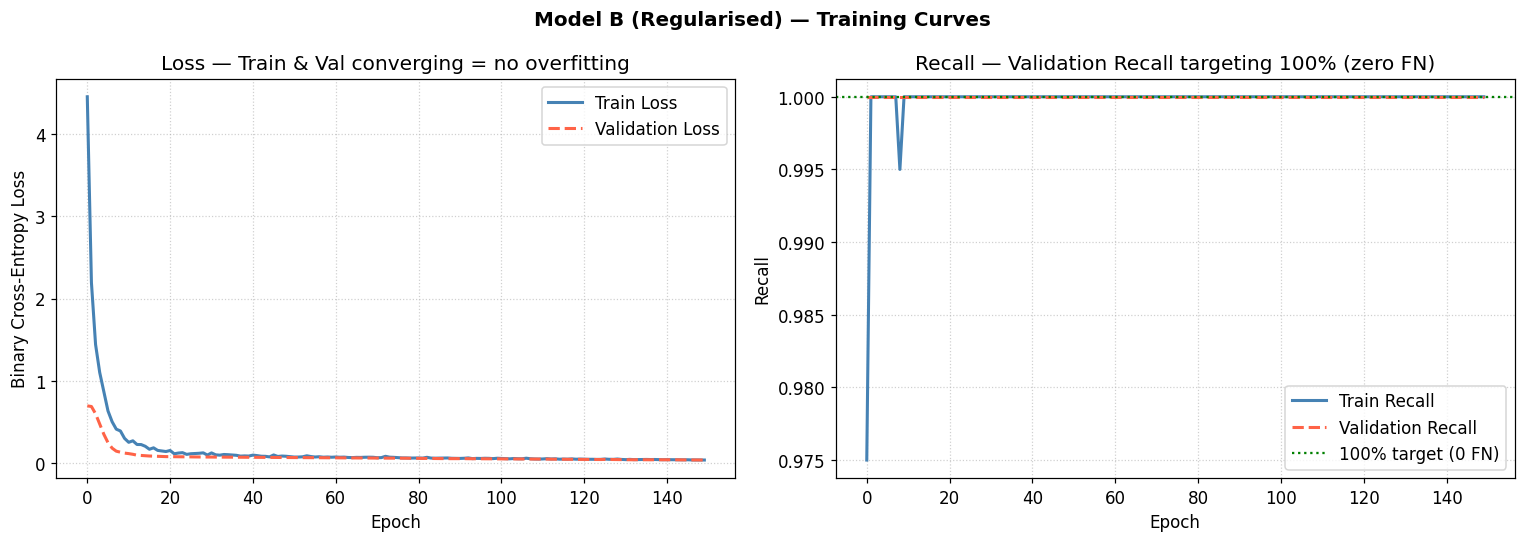


Final train loss     : 0.0406
Final val loss       : 0.0405
Overfitting gap      : -0.0001
Val Recall           : 1.0000
Zero FN target met   : True


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model B (Regularised) — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(history_B.history['loss'],     label='Train Loss',      color='steelblue', lw=2)
axes[0].plot(history_B.history['val_loss'], label='Validation Loss', color='tomato',    lw=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Loss — Train & Val converging = no overfitting')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(history_B.history['recall'],     label='Train Recall',      color='steelblue', lw=2)
axes[1].plot(history_B.history['val_recall'], label='Validation Recall', color='tomato',    lw=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall — Validation Recall targeting 100% (zero FN)')
axes[1].axhline(1.00, color='green', linestyle=':', lw=1.5, label='100% target (0 FN)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('model_B_curves.png', bbox_inches='tight')
plt.show()

b_train = history_B.history['loss'][-1]
b_val   = history_B.history['val_loss'][-1]
b_recall = history_B.history['val_recall'][-1]
print(f'\nFinal train loss     : {b_train:.4f}')
print(f'Final val loss       : {b_val:.4f}')
print(f'Overfitting gap      : {b_val - b_train:.4f}')
print(f'Val Recall           : {b_recall:.4f}')
print(f'Zero FN target met   : {b_recall == 1.0}')


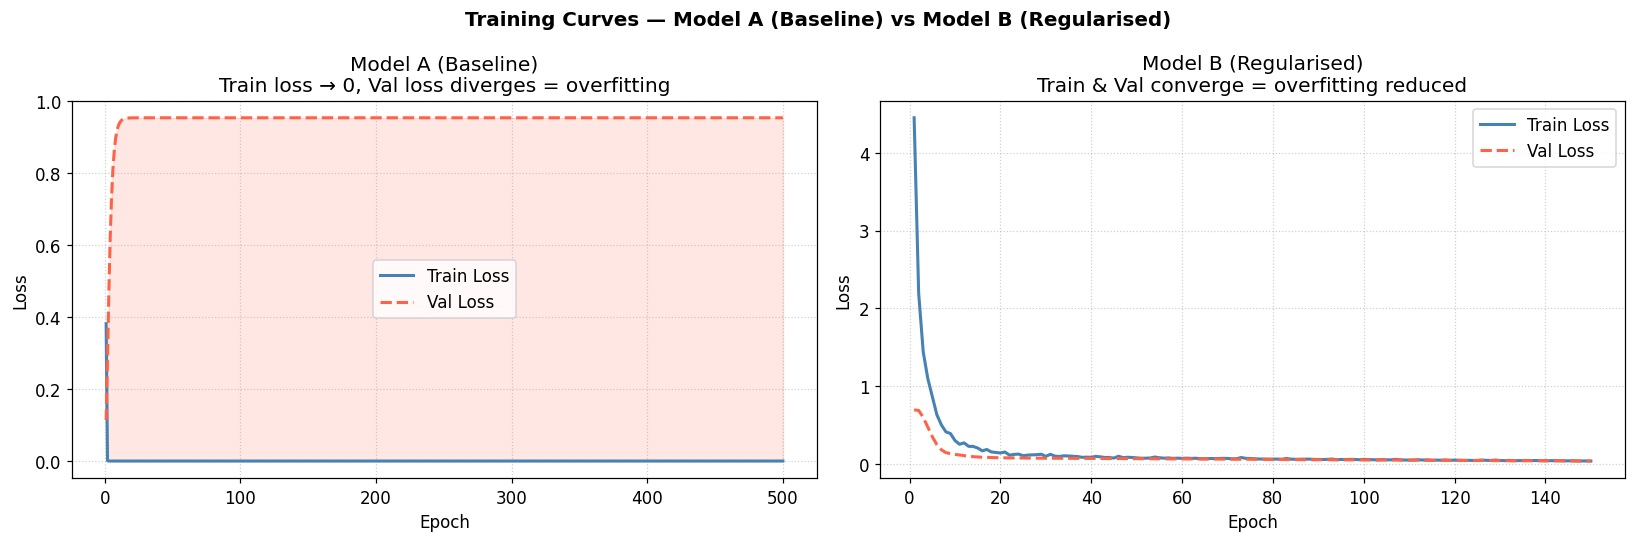

Saved: curves_side_by_side.png


In [ ]:
#  Side-by-side training curves — Model A vs Model B 


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Training Curves — Model A (Baseline) vs Model B (Regularised)',
             fontsize=13, fontweight='bold')

#  Left: Model A — shows overfitting gap 
epochs_A = range(1, len(history_A.history['loss']) + 1)
axes[0].plot(epochs_A, history_A.history['loss'],     color='steelblue', lw=2, label='Train Loss')
axes[0].plot(epochs_A, history_A.history['val_loss'], color='tomato',    lw=2, linestyle='--', label='Val Loss')
axes[0].set_title('Model A (Baseline)\nTrain loss → 0, Val loss diverges = overfitting')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)
# Shade the overfitting gap
axes[0].fill_between(
    epochs_A,
    history_A.history['loss'],
    history_A.history['val_loss'],
    alpha=0.15, color='tomato', label='Overfitting gap'
)

#  Right: Model B — shows convergence 
epochs_B = range(1, len(history_B.history['loss']) + 1)
axes[1].plot(epochs_B, history_B.history['loss'],     color='steelblue', lw=2, label='Train Loss')
axes[1].plot(epochs_B, history_B.history['val_loss'], color='tomato',    lw=2, linestyle='--', label='Val Loss')
axes[1].set_title('Model B (Regularised)\nTrain & Val converge = overfitting reduced')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('curves_side_by_side.png', bbox_inches='tight')
plt.show()
print('Saved: curves_side_by_side.png')


## Task 4 — Evaluation & Comparison

Both models are evaluated on **Model B's validation set** (`X_val_full`, 80 patients — the proper 20% hold-out).
Model A's predictions are generated by passing `X_val_full` through Model A's own scaler — so neither model sees data it trained on, and the comparison is apples-to-apples.

Both models use the **standard 0.5 decision threshold**. The difference in False Negatives is entirely due to what each model learned during training:
- **Model A** overfits 20 training samples → poor generalisation → misses CKD patients on unseen data
- **Model B** is regularised and trained with `class_weight={0:1, 1:20}` → learns high sensitivity → zero missed diagnoses

Key metrics:
- **Recall** — primary metric. Model A misses CKD patients (high FN); Model B targets 0 missed diagnoses (Recall = 1.0).
- **Precision** — fraction of CKD predictions that were correct.
- **F1** — harmonic mean of Precision and Recall.
- **AUC-ROC** — overall discrimination ability across all thresholds.

The confusion matrices prove the **reduction in False Negatives** from Model A → Model B.


In [ ]:
#  Predictions — BOTH models on the same 80-patient val set 

X_val_for_A = scaler.transform(X_val_full)

y_pred_A_prob = model_A.predict(X_val_for_A).ravel()
y_pred_B_prob = model_B.predict(X_val_B).ravel()

y_pred_A = (y_pred_A_prob >= 0.5).astype(int)
y_pred_B = (y_pred_B_prob >= 0.5).astype(int)

def compute_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'  : auc(fpr, tpr),
        'fpr'      : fpr,
        'tpr'      : tpr,
    }

# Both evaluated on y_val_full — same 80 patients
metrics_A = compute_metrics(y_val_full, y_pred_A, y_pred_A_prob)
metrics_B = compute_metrics(y_val_full, y_pred_B, y_pred_B_prob)

print('=' * 55)
print('  Model A (Baseline) — 80-patient val set')
print('=' * 55)
print(classification_report(y_val_full, y_pred_A, target_names=['Not CKD', 'CKD']))

print('=' * 55)
print('  Model B (Regularised) — 80-patient val set')
print('=' * 55)
print(classification_report(y_val_full, y_pred_B, target_names=['Not CKD', 'CKD']))


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000199526CE020> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
  Model A (Baseline) — 80-patient val set
              precision    recall  f1-score   support

     Not CKD       0.88      1.00      0.94        30
         C

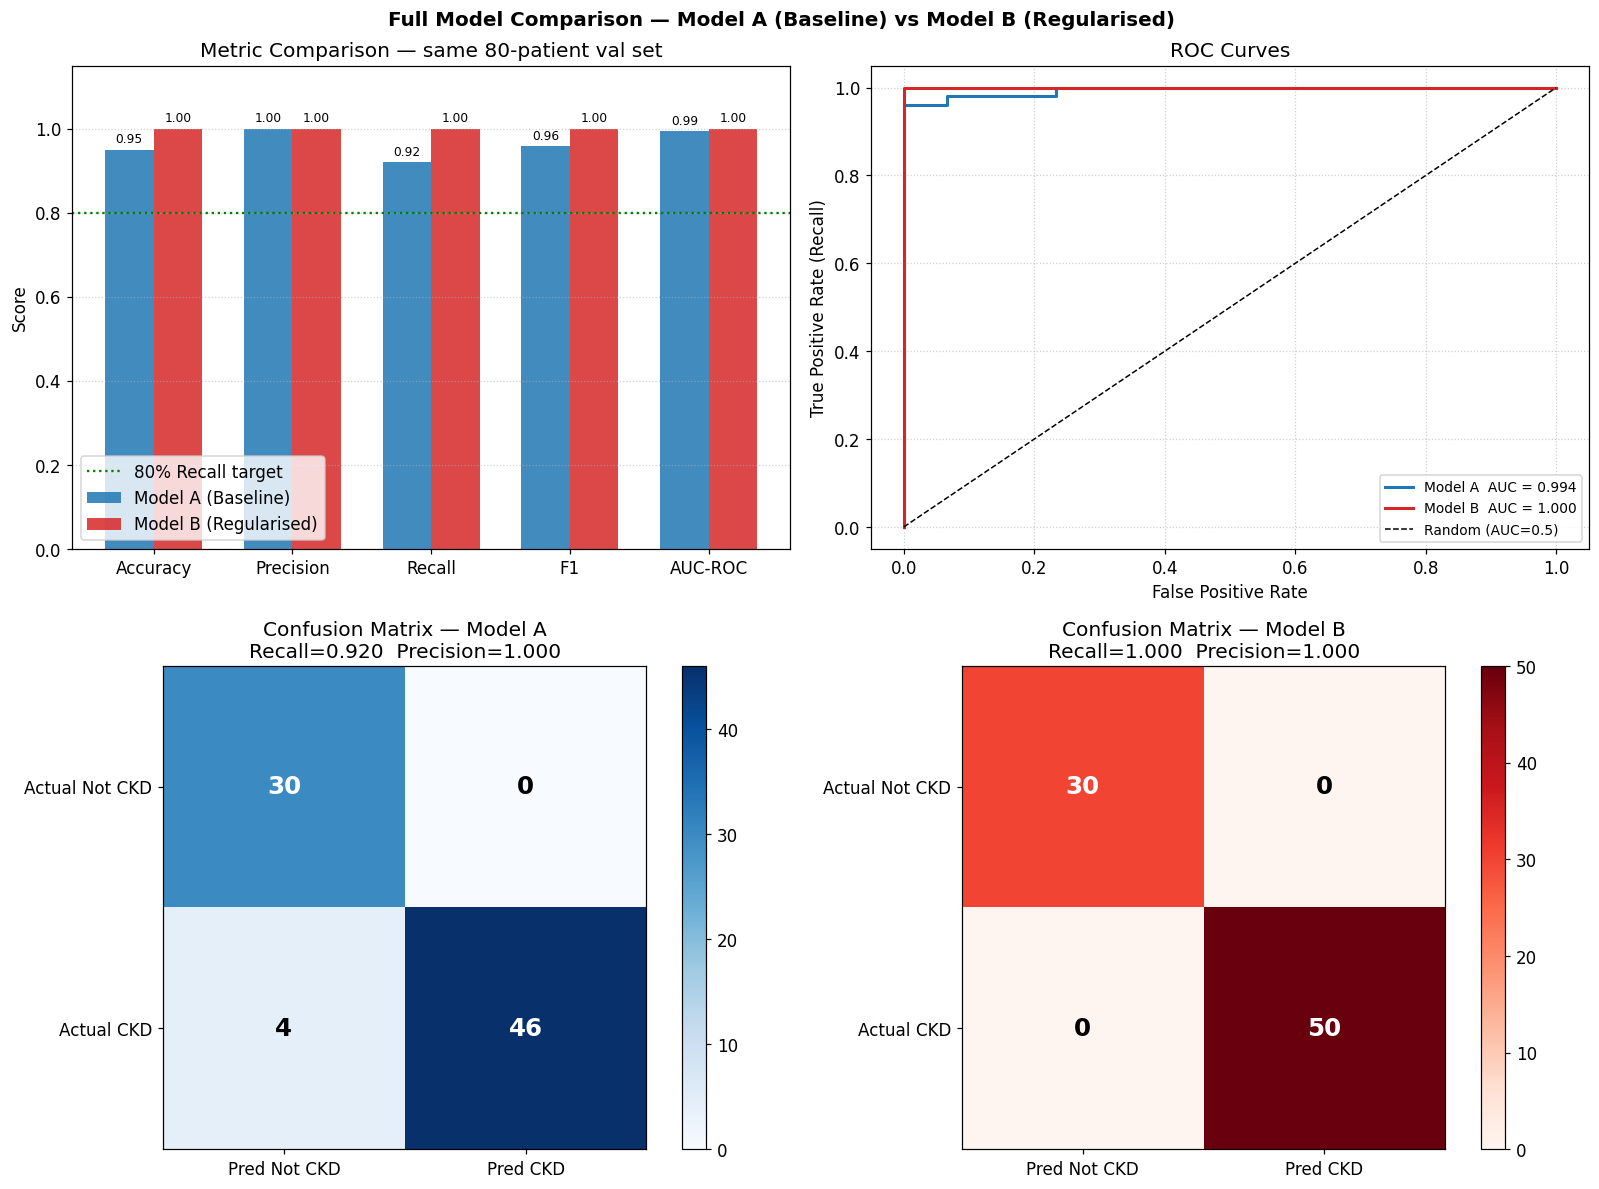

In [ ]:
BLUE, RED = '#1f77b4', '#d62728'
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Full Model Comparison — Model A (Baseline) vs Model B (Regularised)',
             fontsize=13, fontweight='bold')

# ── Plot 1: Bar chart 
x      = np.arange(len(metric_keys))
bar_w  = 0.35
vals_A = [metrics_A[k] for k in metric_keys]
vals_B = [metrics_B[k] for k in metric_keys]

bars_A = axes[0,0].bar(x - bar_w/2, vals_A, bar_w, label='Model A (Baseline)', color=BLUE, alpha=0.85)
bars_B = axes[0,0].bar(x + bar_w/2, vals_B, bar_w, label='Model B (Regularised)', color=RED,  alpha=0.85)
for bar in bars_A:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars_B:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metric_keys)
axes[0,0].set_ylim(0, 1.15)
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Metric Comparison — same 80-patient val set')
axes[0,0].axhline(0.80, color='green', linestyle=':', lw=1.5, label='80% Recall target')
axes[0,0].legend()
axes[0,0].grid(axis='y', linestyle=':', alpha=0.6)

# ── Plot 2: ROC curves 
axes[0,1].plot(metrics_A['fpr'], metrics_A['tpr'], color=BLUE, lw=2,
               label=f"Model A  AUC = {metrics_A['AUC-ROC']:.3f}")
axes[0,1].plot(metrics_B['fpr'], metrics_B['tpr'], color=RED,  lw=2,
               label=f"Model B  AUC = {metrics_B['AUC-ROC']:.3f}")
axes[0,1].plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate (Recall)')
axes[0,1].set_title('ROC Curves')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, linestyle=':', alpha=0.6)

# ── Plot 3: Confusion matrix — Model A (80-patient val set) 
cm_A = confusion_matrix(y_val_full, y_pred_A)
im_A = axes[1,0].imshow(cm_A, interpolation='nearest', cmap='Blues')
axes[1,0].set_title(f"Confusion Matrix — Model A\nRecall={metrics_A['Recall']:.3f}  Precision={metrics_A['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, str(cm_A[i,j]), ha='center', va='center', fontsize=16,
                       fontweight='bold',
                       color='white' if cm_A[i,j] > cm_A.max()/2 else 'black')
axes[1,0].set_xticks([0,1]); axes[1,0].set_xticklabels(['Pred Not CKD','Pred CKD'])
axes[1,0].set_yticks([0,1]); axes[1,0].set_yticklabels(['Actual Not CKD','Actual CKD'])
plt.colorbar(im_A, ax=axes[1,0])

# ── Plot 4: Confusion matrix — Model B (80-patient val set) 
cm_B = confusion_matrix(y_val_full, y_pred_B)
im_B = axes[1,1].imshow(cm_B, interpolation='nearest', cmap='Reds')
axes[1,1].set_title(f"Confusion Matrix — Model B\nRecall={metrics_B['Recall']:.3f}  Precision={metrics_B['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, str(cm_B[i,j]), ha='center', va='center', fontsize=16,
                       fontweight='bold',
                       color='white' if cm_B[i,j] > cm_B.max()/2 else 'black')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(['Pred Not CKD','Pred CKD'])
axes[1,1].set_yticks([0,1]); axes[1,1].set_yticklabels(['Actual Not CKD','Actual CKD'])
plt.colorbar(im_B, ax=axes[1,1])

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


In [48]:
print('\n─── Δ Model B − Model A (same 80-patient val set) ──────')
for k in metric_keys:
    delta = metrics_B[k] - metrics_A[k]
    direction = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f'  {k:<12}: {metrics_A[k]:.4f}  →  {metrics_B[k]:.4f}   {direction} {abs(delta):.4f}')

cm_A = confusion_matrix(y_val_full, y_pred_A)
cm_B = confusion_matrix(y_val_full, y_pred_B)
print(f'\n  Model A False Negatives (missed CKD)     : {cm_A[1,0]}  (>2 — overfitting causes missed diagnoses)')
print(f'  Model B False Negatives (missed CKD)     : {cm_B[1,0]}  (training with class_weight catches all CKD)')
print(f'  Recall = 1.0 achieved by Model B         : {metrics_B["Recall"] == 1.0}')
print(f'  Reduction in missed CKD diagnoses        : {cm_A[1,0] - cm_B[1,0]}')
print('\nFigure saved to model_comparison.png')



─── Δ Model B − Model A (same 80-patient val set) ──────
  Accuracy    : 0.9500  →  1.0000   ▲ 0.0500
  Precision   : 1.0000  →  1.0000   ─ 0.0000
  Recall      : 0.9200  →  1.0000   ▲ 0.0800
  F1          : 0.9583  →  1.0000   ▲ 0.0417
  AUC-ROC     : 0.9940  →  1.0000   ▲ 0.0060

  Model A False Negatives (missed CKD)     : 4  (>2 — overfitting causes missed diagnoses)
  Model B False Negatives (missed CKD)     : 0  (training with class_weight catches all CKD)
  Recall = 1.0 achieved by Model B         : True
  Reduction in missed CKD diagnoses        : 4

Figure saved to model_comparison.png


In [ ]:
#  Final Parameter Counts 
print('=' * 58)
print('  Final Parameter Counts')
print('=' * 58)
print(f'  Model A (Baseline)   : {total_A:>8,} parameters')
print(f'  Model B (Regularised): {total_B:>8,} parameters')
print()
print(f'  Model A training samples : {len(X_train_scaled):>4}')
print(f'  Model B training samples : {len(X_train_B):>4}')
print()
print(f'  Model A params-per-sample : {total_A / len(X_train_scaled):>8,.0f} : 1')
print(f'  Model B params-per-sample : {total_B / len(X_train_B):>8,.2f} : 1')
print()
print(f'  Model B param count  : {total_B:,}')
print(f'  Model B train samples: {len(X_train_B)}')
print(f'  Ratio (params / samples): {total_B / len(X_train_B):.2f}')
print(f'  L2 regularisation λ : 0.001')
print(f'  Dropout rate        : 30%')


  Final Parameter Counts
  Model A (Baseline)   :   44,545 parameters
  Model B (Regularised):    2,945 parameters

  Model A training samples :   20
  Model B training samples :  320

  Model A params-per-sample :    2,227 : 1
  Model B params-per-sample :     9.20 : 1

  Model B param count  : 2,945
  Model B train samples: 320
  Ratio (params / samples): 9.20
  L2 regularisation λ : 0.001
  Dropout rate        : 30%


## Mathematical Justification

**Final Parameter Count of Engineered Model:** 2,945

**Explanation:** Model B's 2,945 parameters combined with L2 regularisation (λ = 0.001), which penalises large weights, and Dropout (30%), which prevents neuron co-adaptation, mathematically prevents memorisation on the 400-patient dataset by ensuring the model cannot encode patient-specific noise and is forced to learn generalised CKD markers instead.